**Lab 2 : Water body segmentation**

In [ ]:
 import kagglehub

# Download latest version
path = kagglehub.dataset_download("gvclsu/water-segmentation-dataset")

print("Path to dataset files:", path)

100%|██████████| 4.77G/4.77G [00:23<00:00, 216MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/gvclsu/water-segmentation-dataset/versions/4


In [ ]:
import os

DATASET_PATH = "/root/.cache/kagglehub/datasets/gvclsu/water-segmentation-dataset/versions/4"

print("Root folders:")
print(os.listdir(DATASET_PATH))


Root folders:
['water_v2', 'water_v1']


In [ ]:
for folder in os.listdir(DATASET_PATH):
    print(folder, "->", os.listdir(os.path.join(DATASET_PATH, folder))[:5])


water_v2 -> ['water_v2']
water_v1 -> ['water_v1']


In [ ]:
['WaterDataset']


['WaterDataset']

In [ ]:
import os

BASE_PATH = "/root/.cache/kagglehub/datasets/gvclsu/water-segmentation-dataset/versions/4"

def explore(path, level=0):
    print("  " * level + os.path.basename(path))
    if level >= 4:
        return
    for item in os.listdir(path):
        full_path = os.path.join(path, item)
        if os.path.isdir(full_path):
            explore(full_path, level+1)

explore(BASE_PATH)


4
  water_v2
    water_v2
      Annotations
        mexico_beach_clip0
        stream3_small
        dublin
        evesham-lock
        cockermouth
        bewdley
        auldgirth
        river_segs
        ADE20K
        buffalo0_small
        stream0
        aberlour
        boston_harbor2_small_rois
        stream1
        canal0
        holmrook
        worcester
        keswick_greta
        stream2
        holiday_inn_clip0
        gulf_crest
        galway-city
      JPEGImages
        mexico_beach_clip0
        stream3_small
        dublin
        evesham-lock
        cockermouth
        bewdley
        auldgirth
        river_segs
        ADE20K
        buffalo0_small
        stream0
        aberlour
        boston_harbor2_small_rois
        stream1
        canal0
        holmrook
        worcester
        keswick_greta
        stream2
        holiday_inn_clip0
        gulf_crest
        galway-city
  water_v1
    water_v1
      Annotations
        creek0
        houston
  

In [ ]:
DATASET_PATH = "/root/.cache/kagglehub/datasets/gvclsu/water-segmentation-dataset/versions/4/water_v2/water_v2"

IMG_PATH = DATASET_PATH + "/JPEGImages"
MASK_PATH = DATASET_PATH + "/Annotations"

import os
print("IMG exists:", os.path.exists(IMG_PATH))
print("MASK exists:", os.path.exists(MASK_PATH))
print("IMG sample folders:", os.listdir(IMG_PATH)[:5])
print("MASK sample folders:", os.listdir(MASK_PATH)[:5])


IMG exists: True
MASK exists: True
IMG sample folders: ['mexico_beach_clip0', 'stream3_small', 'dublin', 'evesham-lock', 'cockermouth']
MASK sample folders: ['mexico_beach_clip0', 'stream3_small', 'dublin', 'evesham-lock', 'cockermouth']


In [ ]:
import cv2
import numpy as np
from tqdm import tqdm

IMG_SIZE = 128

def load_dataset():
    images = []
    masks = []

    scenes = os.listdir(IMG_PATH)

    for scene in tqdm(scenes):
        scene_img_dir = os.path.join(IMG_PATH, scene)
        scene_mask_dir = os.path.join(MASK_PATH, scene)

        if not os.path.isdir(scene_img_dir):
            continue

        for img_name in os.listdir(scene_img_dir):
            img_path = os.path.join(scene_img_dir, img_name)
            mask_path = os.path.join(scene_mask_dir, img_name.replace(".jpg", ".png"))

            if not os.path.exists(mask_path):
                continue

            image = cv2.imread(img_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
            image = image / 255.0

            mask = cv2.imread(mask_path, 0)
            mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
            mask = mask / 255.0
            mask = np.expand_dims(mask, axis=-1)

            images.append(image)
            masks.append(mask)

    return np.array(images), np.array(masks)


In [ ]:
X, Y = load_dataset()
print("Images:", X.shape)
print("Masks:", Y.shape)


100%|██████████| 22/22 [00:38<00:00,  1.76s/it]


Images: (2400, 128, 128, 3)
Masks: (2400, 128, 128, 1)


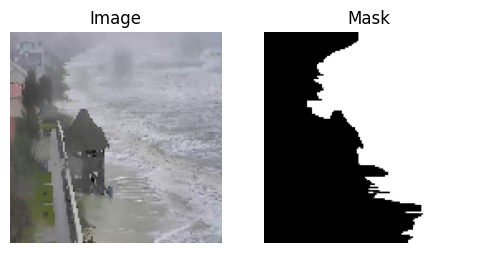

In [ ]:
import matplotlib.pyplot as plt

idx = 0
plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(X[idx])
plt.title("Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(Y[idx].squeeze(), cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.show()


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, Y_train, Y_temp = train_test_split(
    X, Y, test_size=0.3, random_state=42)

X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.5, random_state=42)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)


Train: (1680, 128, 128, 3)
Val: (360, 128, 128, 3)
Test: (360, 128, 128, 3)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
def build_generator():
    inputs = layers.Input((IMG_SIZE, IMG_SIZE, 3))

    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(c1)
    c2 = layers.MaxPooling2D()(c2)

    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(c2)

    u1 = layers.UpSampling2D()(c3)
    u1 = layers.Conv2D(128, 3, activation='relu', padding='same')(u1)

    u2 = layers.UpSampling2D()(u1)
    u2 = layers.Conv2D(64, 3, activation='relu', padding='same')(u2)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(u2)

    return models.Model(inputs, outputs)

generator = build_generator()
generator.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 1)    │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 739,713 (2.82 MB)

 Trainable params: 739,713 (2.82 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def build_discriminator():
    image_input = layers.Input((IMG_SIZE, IMG_SIZE, 3))
    mask_input = layers.Input((IMG_SIZE, IMG_SIZE, 1))

    x = layers.Concatenate()([image_input, mask_input])
    x = layers.Conv2D(64, 3, strides=2, padding='same')(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2D(128, 3, strides=2, padding='same')(x)
    x = layers.LeakyReLU()(x)

    x = layers.Flatten()(x)
    x = layers.Dense(1, activation='sigmoid')(x)

    return models.Model([image_input, mask_input], x)

discriminator = build_discriminator()
discriminator.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 128,  │          0 │ input_layer_1[0]… │
│ (Concatenate)       │ 4)                │            │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 64,    │      2,368 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 64, 64,    │          0 │ conv2d_6[0][0]    │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │     73,856 │ leaky_re_lu[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 32, 32,    │          0 │ conv2d_7[0][0]    │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 131072)    │          0 │ leaky_re_lu_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │    131,073 │ flatten[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 207,297 (809.75 KB)

 Trainable params: 207,297 (809.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras import optimizers
discriminator.compile(
    optimizer=optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

discriminator.trainable = False

img_input = layers.Input((IMG_SIZE, IMG_SIZE, 3))
generated_mask = generator(img_input)
validity = discriminator([img_input, generated_mask])

gan = models.Model(img_input, validity)
gan.compile(
    optimizer=optimizers.Adam(1e-4),
    loss='binary_crossentropy'
)


In [ ]:
EPOCHS = 20
BATCH_SIZE = 8

train_acc = []
val_acc = []

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    idx = np.random.randint(0, X_train.shape[0], BATCH_SIZE)
    real_imgs = X_train[idx]
    real_masks = Y_train[idx]

    fake_masks = generator.predict(real_imgs)

    real_labels = np.ones((BATCH_SIZE, 1))
    fake_labels = np.zeros((BATCH_SIZE, 1))

    d_loss_real = discriminator.train_on_batch([real_imgs, real_masks], real_labels)
    d_loss_fake = discriminator.train_on_batch([real_imgs, fake_masks], fake_labels)

    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    g_loss = gan.train_on_batch(real_imgs, real_labels)

    train_acc.append(d_loss[1])

    print("D loss:", d_loss[0], "D acc:", d_loss[1], "G loss:", g_loss)



Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
D loss: 0.7058877 D acc: 0.49163136 G loss: 0.6057854

Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step    
D loss: 0.7061764 D acc: 0.49190244 G loss: 0.60598165

Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
D loss: 0.70637447 D acc: 0.4921565 G loss: 0.60583985

Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
D loss: 0.70669323 D acc: 0.4923951 G loss: 0.60588247

Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
D loss: 0.7070163 D acc: 0.49076766 G loss: 0.606462

Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
D loss: 0.7070492 D acc: 0.4910326 G loss: 0.6062358

Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
D loss: 0.70737374 D acc: 0.49128276 G loss: 0.605911

Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
D loss: 0.70748985 D acc: 0.49151933 G loss: 0.6056976

Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
D loss: 0.70786405 D acc: 0.49008772 G loss: 0.6060286

Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
D loss: 0.7076695

In [ ]:
def dice_coef(y_true, y_pred):
    smooth = 1e-6
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    intersection = np.sum(y_true * y_pred)
    return (2 * intersection + smooth) / (np.sum(y_true) + np.sum(y_pred) + smooth)

def iou_score(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    intersection = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - intersection
    return intersection / union


In [ ]:
pred_masks = generator.predict(X_test)
pred_masks = (pred_masks > 0.5).astype(np.float32)

dice_scores = []
iou_scores = []

for i in range(len(X_test)):
    dice_scores.append(dice_coef(Y_test[i], pred_masks[i]))
    iou_scores.append(iou_score(Y_test[i], pred_masks[i]))

print("Average Dice Score:", np.mean(dice_scores))
print("Average IoU Score:", np.mean(iou_scores))


12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step
Average Dice Score: 0.0010397430345065227
Average IoU Score: 0.0005220200732209666


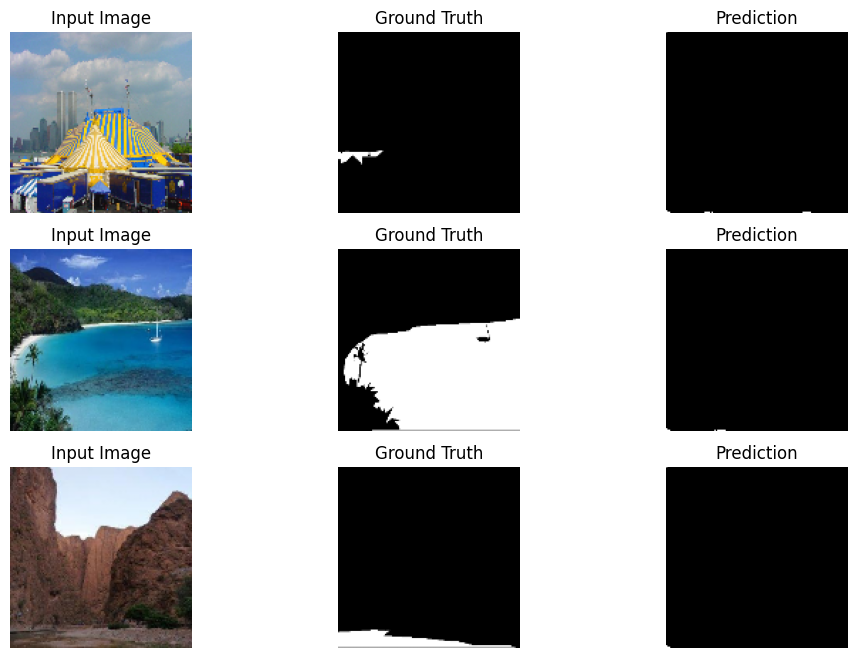

In [ ]:
n = 3
plt.figure(figsize=(12,8))

for i in range(n):
    plt.subplot(n,3,i*3+1)
    plt.imshow(X_test[i])
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(n,3,i*3+2)
    plt.imshow(Y_test[i].squeeze(), cmap='gray')
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(n,3,i*3+3)
    plt.imshow(pred_masks[i].squeeze(), cmap='gray')
    plt.title("Prediction")
    plt.axis("off")

plt.show()
